# **Pavan S - 24BAD085**

---

# **Scenario 1: User-Based Collaborative Filtering**

## Importing Libraries

In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

## Loading the Dataset

In [30]:
ratings = pd.read_csv('/content/ratings.csv')
movies = pd.read_csv('/content/movies.csv')

df = pd.merge(ratings, movies, on='movieId')

df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [36]:
print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)

Ratings Shape: (100836, 4)
Movies Shape: (9742, 3)


## Data Inspection

In [72]:
print(ratings.head())
print(ratings.isnull().sum())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [73]:
print(df.shape)
print(df['rating'].describe())
print(df['userId'].nunique())
print(df['movieId'].nunique())

(100836, 6)
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64
610
9724


## Create User-Item Matrix

In [40]:
user_item_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)
user_item_matrix.shape


(610, 9724)

## Handle Missing Values

In [50]:
user_item = user_item_matrix.fillna(0)
user_item.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Compute User Similarity

In [51]:
user_similarity = cosine_similarity(user_item)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item.index,
    columns=user_item.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [52]:
user_similarity_df.shape

(610, 610)

## Find Similar Users

In [ ]:
def get_similar_users(user_id, n=5):
    return user_similarity_df[user_id] \
        .sort_values(ascending=False)[1:n+1]

get_similar_users(1)

,1
userId,
348,0.413838
506,0.411054
493,0.406140
158,0.404324
633,0.402729


## Predict Ratings & Recommend Movies

In [60]:
def predict_ratings(user_id, n_neighbors=5):
    similar_users = get_similar_users(user_id, n_neighbors)

    user_ratings = user_item.loc[user_id]

    predicted_ratings = {}

    for movie in user_item.columns:
        if user_ratings[movie] == 0:  # unseen movie
            weighted_sum = 0
            similarity_sum = 0

            for sim_user, sim_score in similar_users.items():
                rating = user_item.loc[sim_user, movie]
                if rating > 0:
                    weighted_sum += sim_score * rating
                    similarity_sum += sim_score

            if similarity_sum > 0:
                predicted_ratings[movie] = weighted_sum / similarity_sum

    return predicted_ratings

In [61]:
def recommend_movies(user_id, n=5):
    preds = predict_ratings(user_id)

    sorted_preds = sorted(preds.items(), key=lambda x: x[1], reverse=True)

    top_movies = sorted_preds[:n]

    movie_ids = [movie[0] for movie in top_movies]

    return movies[movies['movieId'].isin(movie_ids)]


recommend_movies(1, 5)

,movieId,title,genres
449,514,"Ref, The (1994)",Comedy
474,541,Blade Runner (1982),Action|Sci-Fi|Thriller
585,720,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War
659,858,"Godfather, The (1972)",Crime|Drama


## Evaluation

In [63]:
def fast_evaluate(sample_size=500):

    sample_data = ratings.sample(sample_size, random_state=42)

    actual = []
    predicted = []

    for _, row in sample_data.iterrows():
        user = row['userId']
        movie = row['movieId']
        true_rating = row['rating']

        similar_users = get_similar_users(user, 5)

        weighted_sum = 0
        similarity_sum = 0

        for sim_user, sim_score in similar_users.items():
            rating = user_item.loc[sim_user, movie]

            if rating > 0:
                weighted_sum += sim_score * rating
                similarity_sum += sim_score

        if similarity_sum > 0:
            pred = weighted_sum / similarity_sum

            actual.append(true_rating)
            predicted.append(pred)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    print(rmse)
    print(mae)

fast_evaluate()


Fast Evaluation Results:
RMSE: 0.9794814972188755
MAE: 0.7464345904919917


## Visualization

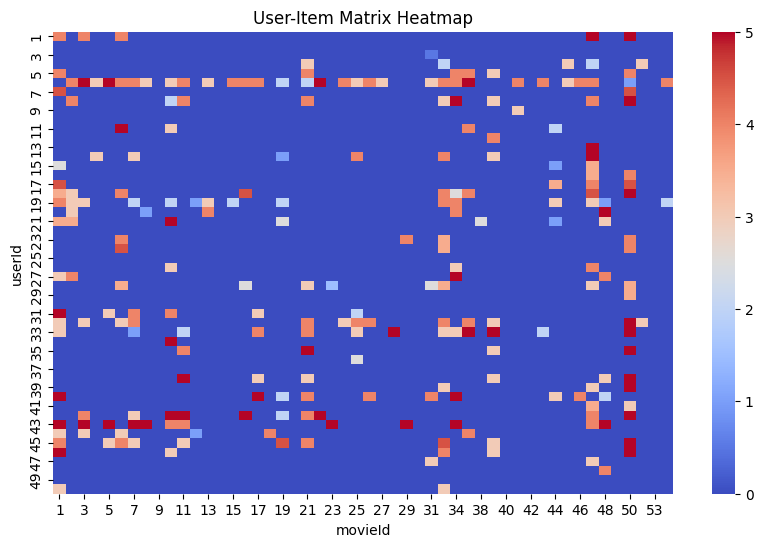

In [65]:
plt.figure(figsize=(10, 6))
sns.heatmap(user_item.iloc[:50, :50],cmap='coolwarm')
plt.title("User-Item Matrix Heatmap")
plt.show()

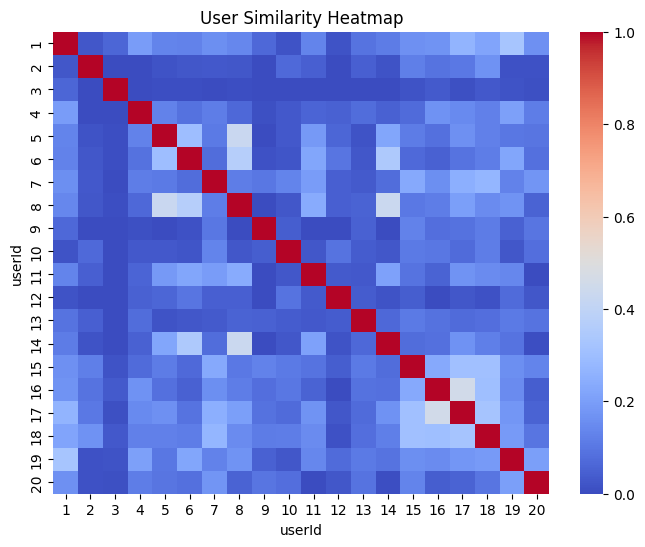

In [67]:
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("User Similarity Heatmap")
plt.show()

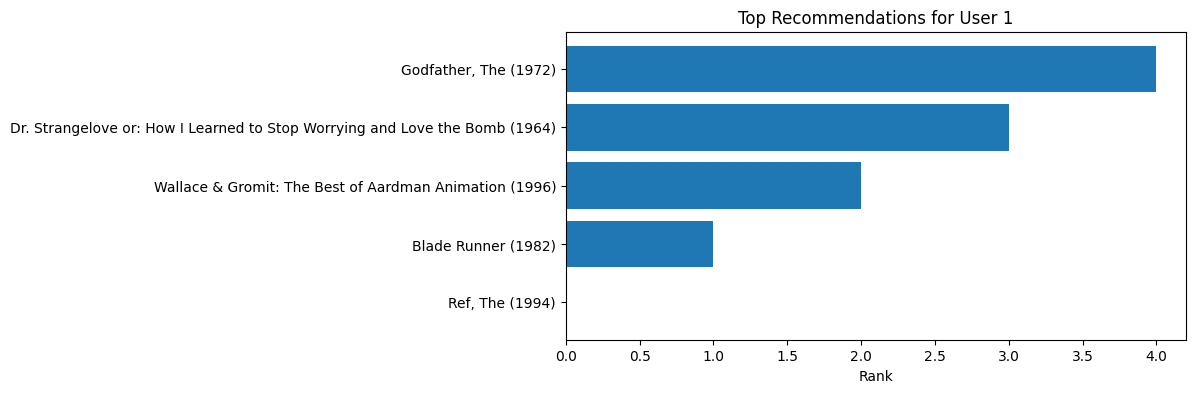

In [71]:
def plot_recommendations(user_id):
    recs = recommend_movies(user_id, 5)

    plt.figure(figsize=(8,4))
    plt.barh(recs['title'], range(len(recs)))
    plt.title(f"Top Recommendations for User {user_id}")
    plt.xlabel("Rank")
    plt.show()

plot_recommendations(1)